# Predição de ativos da bolsa de valores

## Import Libraries

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import plot
import plotly.graph_objects as go

import datetime
import pandas as pd
from sklearn.utils import class_weight
import utils


In [2]:
import xgboost as xgb
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, MaxPooling1D, Activation, MaxPooling1D, Dropout, Flatten, BatchNormalization, GRU, AveragePooling1D, SpatialDropout1D, GlobalAveragePooling1D
#from tensorflow.keras.initializers import he_uniform
from tensorflow import keras

In [3]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from DataLoaderPipeline import FeaturesDataGenerator, scrapingHistoricalData

## Init parameters

In [ ]:
# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', ]
                    #'Volume_log','Chaikin_Money_Flow', 'Williams_R,'PPO',]


# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low',
                    
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
 
                    'RSI_14' ,
                    'MACD', 'MACD_Signal', 'MACD_Histogram',
 
                    'Stochastic_K', 'Stochastic_D',
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC']  

features_indicators=[#'Close', 'Open', 'High', 'Low',
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'MACD_Signal', 'MACD_Histogram', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', 'Chaikin_Money_Flow',
                    'SCP', 'MFI', 'RSI_14', 'Williams_R','MACD',]


#features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD']
                    # 'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350']




In [5]:
'''### best
pred_days = 7
buy_sell_threshold=[0.05,-0.05]
lookback = 20
batch_size = 8
shuffle = True
data_augmentation = True

min_norm=-1
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)'''

"### best\npred_days = 7\nbuy_sell_threshold=[0.05,-0.05]\nlookback = 20\nbatch_size = 8\nshuffle = True\ndata_augmentation = True\n\nmin_norm=-1\nmax_norm=1\n\ntrade=['Hold','Buy','Sell']\n\n# model parameters\ninput_shape = (lookback, len(features_indicators))\nn_classes = len(trade)"

In [6]:


#pred_days = int(24/4 * 3)
pred_days = int(24/4 * 11)
#pred_days = 11
buy_sell_threshold=[0.05,-0.05]
lookback = 20
batch_size = 4

shuffle = True
data_augmentation = False

min_norm=-1
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)



In [7]:
input_shape

(20, 20)

## Deep Learning Model

In [8]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="Attention_")
class Attention_(tf.keras.layers.Layer):
    def __init__(self, units,  **kwargs):
        super(Attention_, self).__init__( **kwargs)
        self.units = units
        self.W = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def build(self, input_shape):
        self.W.build(input_shape)
        self.V.build(input_shape)

    def call(self, inputs):
        # Compute attention scores
        score = tf.nn.tanh(self.W(inputs))
        attention_weights = tf.nn.softmax(self.V(score), axis=-1)

        # Apply attention weights to input
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=-1)

        return context_vector

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [9]:
# Model name
model_name = "CNN_MultiHead"
#np.random.seed(42)

# Importe as bibliotecas necessárias
from keras.layers import Dropout
from keras.regularizers import l2

# Defina a taxa de dropout
dropout_rate = 0.2

# Defina a magnitude da L2 regularization
l2_regularization = 0.01

# Aplique o dropout às camadas do modelo
def common_layers(input1):
    # ...
    conv_layer = Conv1D(64, (3), padding="same")(input1)
    conv_layer = BatchNormalization()(conv_layer)
    conv_layer = Activation('relu')(conv_layer)
    conv_layer = MaxPooling1D(pool_size=(3), strides=1, padding="same")(conv_layer)
    conv_layer = Dropout(dropout_rate)(conv_layer)  

    conv_layer = Conv1D(128, (3), padding="same")(input1)
    conv_layer = BatchNormalization()(conv_layer)
    conv_layer = Activation('relu')(conv_layer)
    conv_layer = MaxPooling1D(pool_size=(3), strides=2, padding="same")(conv_layer)
    conv_layer = Dropout(dropout_rate)(conv_layer)  # Adicione o dropout aqui
    # ...
    return conv_layer

def head_layer(conv_layer, num_classes, activation='linear', output_name=None):
    # ...
    head = Conv1D(32, (3), padding="same")(conv_layer)
    head = BatchNormalization()(head)
    head = Activation('relu')(head)
    head = MaxPooling1D(pool_size=(3), strides=2, padding="same")(head)
    head = Dropout(dropout_rate)(head)  # Adicione o dropout aqui
    # ...
    #head=Attention_(units=64)(head)
    #head=Attention_(units=32)(head)
    head = Flatten()(input_data)
    # Adicione a L2 regularization às camadas densas
    x = Dense(256, kernel_regularizer=l2(l2_regularization))(head)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)  # Adicione o dropout aqui

    x = Dense(128, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)  # Adicione o dropout aqui

    x = Dense(num_classes)(x)
    x = Activation(activation, name=output_name)(x)

    return x

# Create the full model
input_data = Input(shape=input_shape)

Features = common_layers(input_data)
# Create separate heads with appropriate number of outputs and activations
#regression_output = head_layer(Features, num_classes=pred_days, activation='linear',output_name='regression_head')
classification_output = head_layer(Features, num_classes=n_classes, activation='softmax',output_name='classification_head')

# Create the model with two heads
model_CNN_MultiHead = Model(inputs=input_data, outputs=[classification_output])
model_CNN_MultiHead._name = model_name

# Print model summary
model_CNN_MultiHead.summary()



Model: "CNN_MultiHead"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 20)]          0         
                                                                 
 flatten (Flatten)           (None, 400)               0         
                                                                 
 dense (Dense)               (None, 256)               102656    
                                                                 
 batch_normalization_3 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 activation_3 (Activation)   (None, 256)               0         
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                   

In [10]:
#Metrics and Loss Functions  

from tensorflow.keras import backend as K

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

def R2(y_true, y_pred): # squareds Pearson's correlation coef 
    SS_res =  K.sum(K.square( y_true-y_pred ))
    SS_tot = K.sum(K.square( y_true - K.mean(y_true) ) )
    return ( 1 - SS_res/(SS_tot - K.epsilon()) )

def NRMSE(y_true, y_pred): # normalized_root_mean_squared_error
    return 1-K.sqrt(K.mean(K.square(y_pred - y_true))) 

MSE= tf.keras.losses.mean_squared_error
MAE = tf.keras.losses.mean_absolute_error
MAPE = tf.keras.losses.mean_absolute_percentage_error

In [11]:
#Optimizers
def get_optimizer():
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, amsgrad=True, name="Adam")
    #optimizer1 = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    #optimizer = optimizers.SGD(lr=params["lr"], decay=1e-6, momentum=0.9, nesterov=True)

    return optimizer1
    #

#Train options callbacks

    # Avalia se está tendo avanção de desempenho no treinamento/validação e para caso não tenha avanço 
EarlyStopping=tf.keras.callbacks.EarlyStopping( monitor="val_loss", patience=20, verbose=1, mode="min", restore_best_weights=True,)

    # verifica se está tendo avanço de desempenho durante o treinamento, caso não reduz integralmente o lr
reduceLr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor = 0.01, patience = 5, min_lr=1e-20,verbose=1)



def checkpoints(model_name):
    checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}'
    csvLogger = tf.keras.callbacks.CSVLogger(checkpoint_filepath+'_history.csv', separator=',',append=True)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_weights_only=False, monitor='val_loss', mode='min', save_best_only=True)
    print("Training model :", checkpoint_filepath)

    return csvLogger, model_checkpoint_callback


In [12]:
f'models/model_{model_name}_crypto_lookback_{lookback}'

'models/model_CNN_MultiHead_crypto_lookback_20'

In [13]:
list_of_models=[model_CNN_MultiHead]

## Load Data And train

In [14]:
SHD=scrapingHistoricalData()

# Lista de criptomoedas
interval = '4h'

#df=SHD.get_crypto_historical_data(cryptos, interval, '2015-01-01')


In [15]:
import datetime
init_date = '2015-01-01'
init_date_object = datetime.datetime.strptime(init_date, '%Y-%m-%d').date()

date_now = datetime.date.today()

diff_years = date_now.year - init_date_object.year
year_window = 5


#cryptos_list = [ 'BTC','ETH','SOL','DOT','FET']
cryptos_list = ['BTC']

if year_window > diff_years:
    raise ValueError("O intervalo de anos (year_window) é maior do que o período disponível nos dados.")


In [16]:

# Caminho do arquivo
file_folder = f'Data_history/{cryptos_list[0]}_{interval}.csv'

BTC Dataset Period:2015-01-01 : 2020-01-01
Donwload the file Data_history/BTC_4h.csv from bincance history.
20
Calculating labels
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (3867,)
Vall data shape (484,)
Test data shape (485,)
3867
Calculating labels
self.pred_days 66


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:109: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:938: RuntimeWarning:

divide by zero encountered in log



input data shape (3847, 20, 20)
output data shape (3847, 3)
484
Calculating labels
self.pred_days 66
input data shape (464, 20, 20)
output data shape (464, 3)
485
Calculating labels
self.pred_days 66
input data shape (465, 20, 20)
output data shape (465, 3)
[0 1 2] [3768   40   39]
[ 0.34032201 32.05833333 32.88034188]
Training model : models/model_CNN_MultiHead_crypto_lookback_20
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200



Epoch 1: val_loss improved from inf to 5.64854, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


961/961 - 10s - loss: 5.6139 - accuracy: 0.4670 - matthews_correlation_coefficient: 0.1758 - val_loss: 5.6485 - val_accuracy: 0.2457 - val_matthews_correlation_coefficient: -1.1152e-01 - lr: 1.0000e-04 - 10s/epoch - 11ms/step
Epoch 2/200

Epoch 2: val_loss improved from 5.64854 to 5.53193, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


...

961/961 - 8s - loss: 3.7166 - accuracy: 0.7732 - matthews_correlation_coefficient: 0.6572 - val_loss: 4.5749 - val_accuracy: 0.6207 - val_matthews_correlation_coefficient: 0.4293 - lr: 1.0000e-04 - 8s/epoch - 9ms/step
Epoch 14/200

Epoch 14: val_loss did not improve from 4.57485
961/961 - 5s - loss: 3.5964 - accuracy: 0.7724 - matthews_correlation_coefficient: 0.6616 - val_loss: 4.6345 - val_accuracy: 0.6336 - val_matthews_correlation_coefficient: 0.4556 - lr: 1.0000e-04 - 5s/epoch - 5ms/step
Epoch 15/200

Epoch 15: val_loss did not improve from 4.57485
961/961 - 5s - loss: 3.4956 - accuracy: 0.7963 - matthews_correlation_coefficient: 0.6926 - val_loss: 4.8344 - val_accuracy: 0.7392 - val_matthews_correlation_coefficient: 0.6088 - lr: 1.0000e-04 - 5s/epoch - 5ms/step
Epoch 16/200

Epoch 16: val_loss improved from 4.57485 to 4.56909, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


961/961 - 7s - loss: 3.4758 - accuracy: 0.7927 - matthews_correlation_coefficient: 0.6866 - val_loss: 4.5691 - val_accuracy: 0.6810 - val_matthews_correlation_coefficient: 0.5216 - lr: 1.0000e-04 - 7s/epoch - 7ms/step
Epoch 17/200

Epoch 17: val_loss improved from 4.56909 to 4.04769, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


961/961 - 8s - loss: 3.3776 - accuracy: 0.8205 - matthews_correlation_coefficient: 0.7277 - val_loss: 4.0477 - val_accuracy: 0.7478 - val_matthews_correlation_coefficient: 0.6266 - lr: 1.0000e-04 - 8s/epoch - 8ms/step
Epoch 18/200

Epoch 18: val_loss did not improve from 4.04769
961/961 - 5s - loss: 3.2738 - accuracy: 0.8267 - matthews_correlation_coefficient: 0.7413 - val_loss: 4.1812 - val_accuracy: 0.7823 - val_matthews_correlation_coefficient: 0.6674 - lr: 1.0000e-04 - 5s/epoch - 5ms/step
Epoch 19/200

Epoch 19: val_loss did not improve from 4.04769
961/961 - 6s - loss: 3.1782 - accuracy: 0.8658 - matthews_correlation_coefficient: 0.7964 - val_loss: 4.6736 - val_accuracy: 0.7845 - val_matthews_correlation_coefficient: 0.6672 - lr: 1.0000e-04 - 6s/epoch - 6ms/step
Epoch 20/200

Epoch 20: val_loss did not improve from 4.04769
961/961 - 5s - loss: 3.1253 - accuracy: 0.8699 - matthews_correlation_coefficient: 0.8037 - val_loss: 4.2423 - val_accuracy: 0.7888 - val_matthews_correlation_c

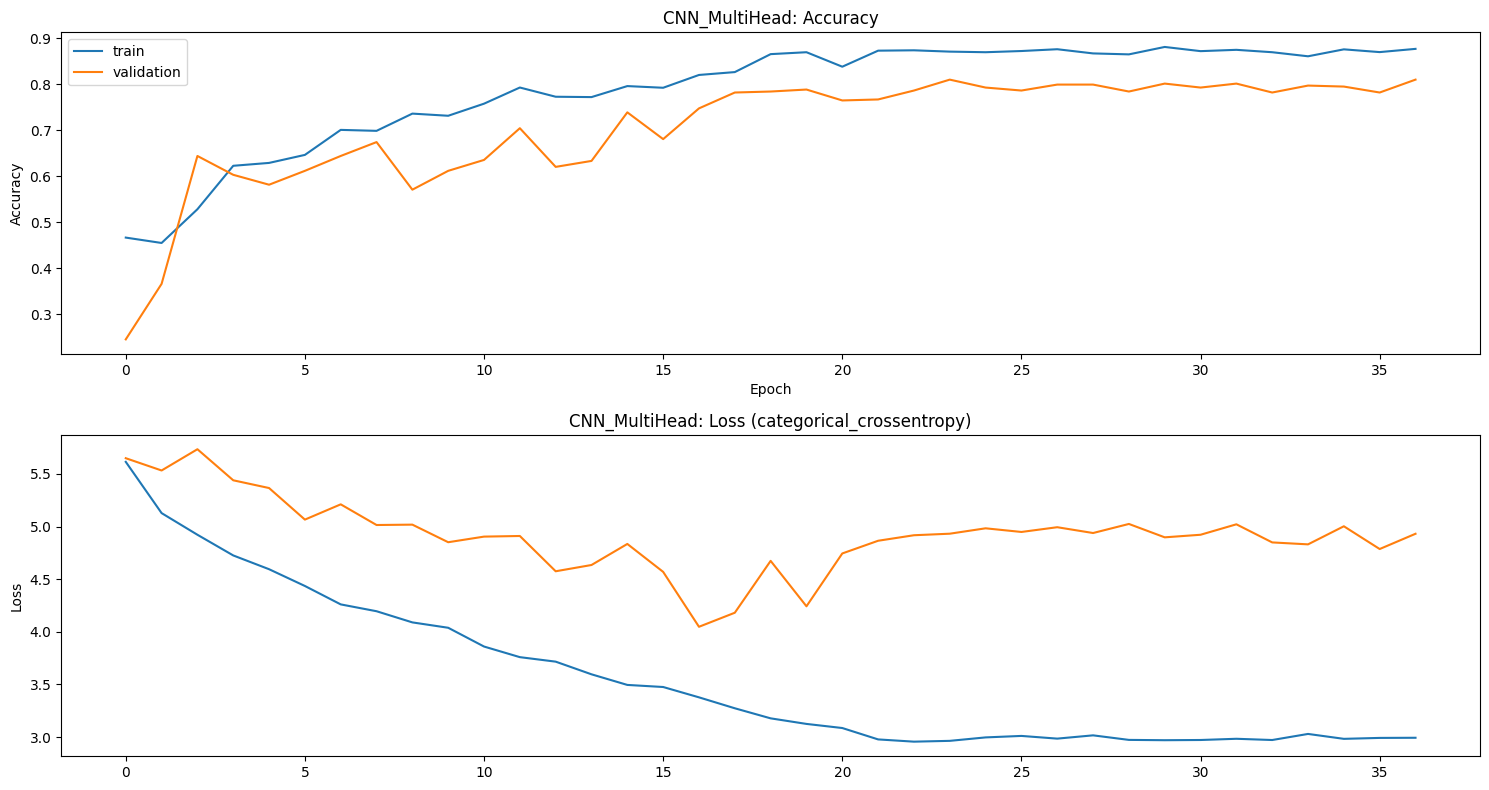

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead



Model name: CNN_MultiHead
15/15 [==============================] - 0s 3ms/step
CNN_MultiHead  classification Accuracy 0.7591397849462366
BTC Dataset Period:2016-01-01 : 2021-01-01
Donwload the file Data_history/BTC_4h.csv from bincance history.
20
Calculating labels
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (5462,)
Vall data shape (684,)
Test data shape (684,)
5462
Calculating labels
self.pred_days 66


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:109: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:938: RuntimeWarning:

divide by zero encountered in log



input data shape (5442, 20, 20)
output data shape (5442, 3)
684
Calculating labels
self.pred_days 66
input data shape (664, 20, 20)
output data shape (664, 3)
684
Calculating labels
self.pred_days 66
input data shape (664, 20, 20)
output data shape (664, 3)
[0 1 2] [5328   58   56]
[ 0.34046547 31.27586207 32.39285714]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200

Epoch 1: val_loss did not improve from 4.04769
1360/1360 - 9s - loss: 3.3318 - accuracy: 0.8268 - matthews_correlation_coefficient: 0.7384 - val_loss: 4.6484 - val_accuracy: 0.7425 - val_matthews_correlation_coefficient: 0.6091 - lr: 1.0000e-04 - 9s/epoch - 7ms/step
Epoch 2/200

Epoch 2: val_loss did not improve from 4.04769
1360/1360 - 7s - loss: 3.1381 - accuracy: 0.7726 - matthews_correlation_coefficient: 0.6580 - val_loss: 4.1174 - val_accuracy: 0.802

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1360/1360 - 9s - loss: 3.0091 - accuracy: 0.7743 - matthews_correlation_coefficient: 0.6604 - val_loss: 3.9401 - val_accuracy: 0.8238 - val_matthews_correlation_coefficient: 0.7206 - lr: 1.0000e-04 - 9s/epoch - 7ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 3.94007
1360/1360 - 7s - loss: 2.8740 - accuracy: 0.7971 - matthews_correlation_coefficient: 0.6934 - val_loss: 4.0043 - val_accuracy: 0.7952 - val_matthews_correlation_coefficient: 0.6960 - lr: 1.0000e-04 - 7s/epoch - 5ms/step
Epoch 5/200

Epoch 5: val_loss did not improve from 3.94007
1360/1360 - 7s - loss: 2.7990 - accuracy: 0.7728 - matthews_correlation_coefficient: 0.6590 - val_loss: 4.2385 - val_accuracy: 0.8554 - val_matthews_correlation_coefficient: 0.7831 - lr: 1.0000e-04 - 7s/epoch - 5ms/step
Epoch 6/200

Epoch 6: val_loss improved from 3.94007 to 3.65929, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1360/1360 - 10s - loss: 2.6625 - accuracy: 0.8180 - matthews_correlation_coefficient: 0.7276 - val_loss: 3.6593 - val_accuracy: 0.8434 - val_matthews_correlation_coefficient: 0.7651 - lr: 1.0000e-04 - 10s/epoch - 7ms/step
Epoch 7/200

Epoch 7: val_loss did not improve from 3.65929
1360/1360 - 7s - loss: 2.7106 - accuracy: 0.7746 - matthews_correlation_coefficient: 0.6609 - val_loss: 3.8153 - val_accuracy: 0.7651 - val_matthews_correlation_coefficient: 0.6365 - lr: 1.0000e-04 - 7s/epoch - 5ms/step
Epoch 8/200

Epoch 8: val_loss improved from 3.65929 to 3.39547, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1360/1360 - 9s - loss: 2.5410 - accuracy: 0.8033 - matthews_correlation_coefficient: 0.7033 - val_loss: 3.3955 - val_accuracy: 0.7756 - val_matthews_correlation_coefficient: 0.6803 - lr: 1.0000e-04 - 9s/epoch - 6ms/step
Epoch 9/200

Epoch 9: val_loss did not improve from 3.39547
1360/1360 - 7s - loss: 2.4340 - accuracy: 0.8333 - matthews_correlation_coefficient: 0.7462 - val_loss: 4.0537 - val_accuracy: 0.8163 - val_matthews_correlation_coefficient: 0.7280 - lr: 1.0000e-04 - 7s/epoch - 5ms/step
Epoch 10/200

Epoch 10: val_loss did not improve from 3.39547
1360/1360 - 7s - loss: 2.3728 - accuracy: 0.8412 - matthews_correlation_coefficient: 0.7611 - val_loss: 4.5188 - val_accuracy: 0.8780 - val_matthews_correlation_coefficient: 0.8170 - lr: 1.0000e-04 - 7s/epoch - 5ms/step
Epoch 11/200

Epoch 11: val_loss did not improve from 3.39547
1360/1360 - 7s - loss: 2.2955 - accuracy: 0.8494 - matthews_correlation_coefficient: 0.7721 - val_loss: 4.1140 - val_accuracy: 0.8855 - val_matthews_correla

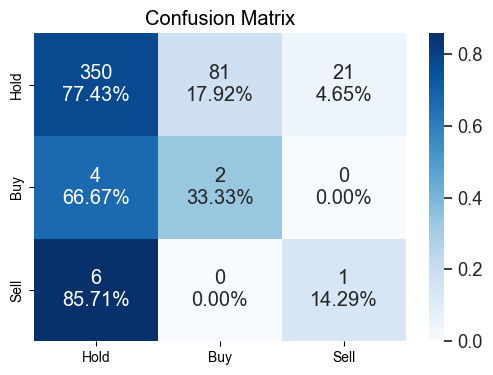

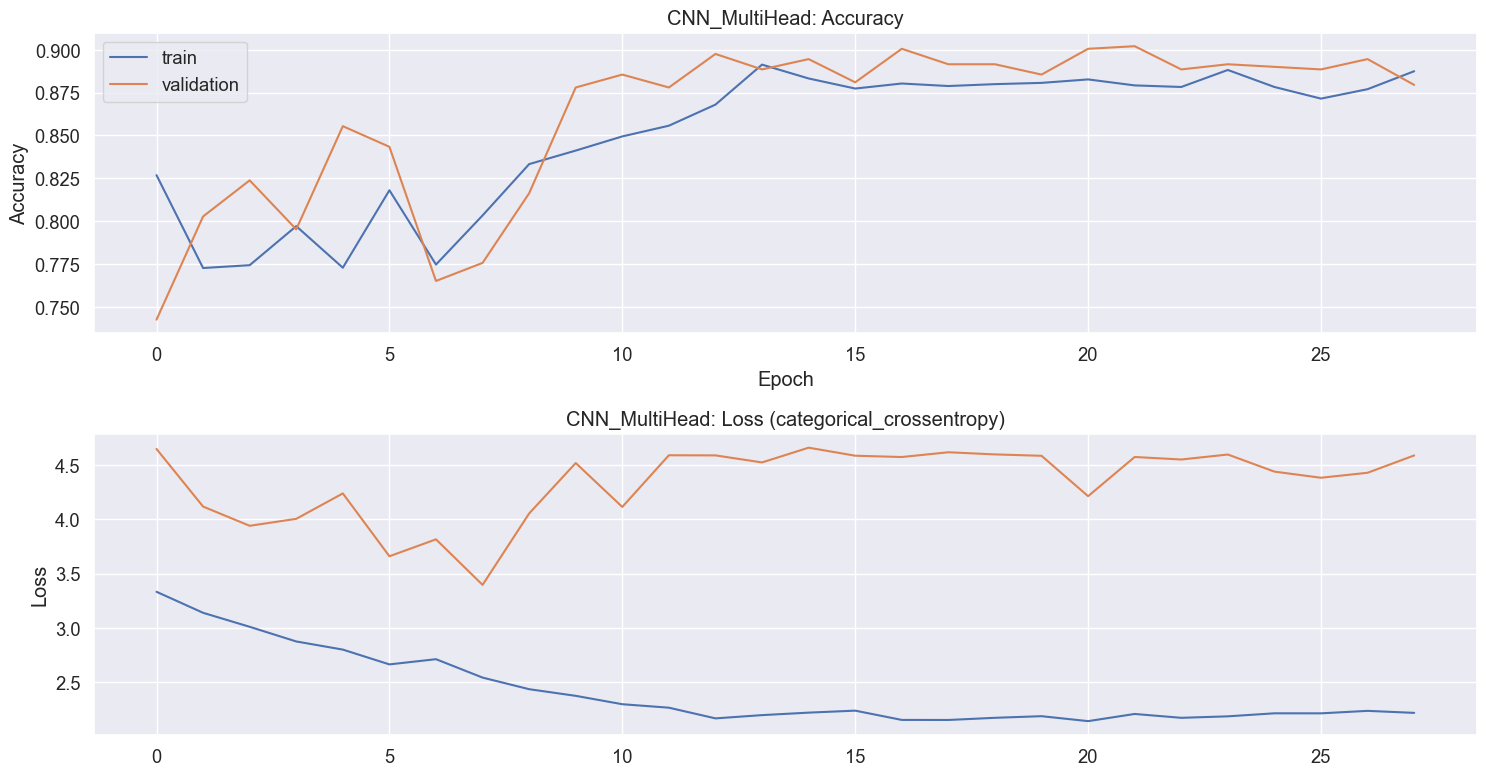

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead
Model name: CNN_MultiHead
21/21 [==============================] - 0s 3ms/step
CNN_MultiHead  classification Accuracy 0.7108433734939759
BTC Dataset Period:2017-01-01 : 2022-01-01
Donwload the file Data_history/BTC_4h.csv from bincance history.
20
Calculating labels
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (7062,)
Vall data shape (884,)
Test data shape (884,)
7062
Calculating labels
self.pred_days 66


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:109: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:938: RuntimeWarning:

divide by zero encountered in log



input data shape (7042, 20, 20)
output data shape (7042, 3)
884
Calculating labels
self.pred_days 66
input data shape (864, 20, 20)
output data shape (864, 3)
884
Calculating labels
self.pred_days 66
input data shape (864, 20, 20)
output data shape (864, 3)
[0 1 2] [6900   72   70]
[ 0.34019324 32.60185185 33.53333333]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200

Epoch 1: val_loss improved from 3.39547 to 3.27968, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1760/1760 - 15s - loss: 2.4230 - accuracy: 0.8513 - matthews_correlation_coefficient: 0.7758 - val_loss: 3.2797 - val_accuracy: 0.8565 - val_matthews_correlation_coefficient: 0.7877 - lr: 1.0000e-04 - 15s/epoch - 8ms/step
Epoch 2/200

Epoch 2: val_loss did not improve from 3.27968
1760/1760 - 9s - loss: 2.2533 - accuracy: 0.8212 - matthews_correlation_coefficient: 0.7306 - val_loss: 3.3725 - val_accuracy: 0.8530 - val_matthews_correlation_coefficient: 0.7831 - lr: 1.0000e-04 - 9s/epoch - 5ms/step
Epoch 3/200

Epoch 3: val_loss did not improve from 3.27968
1760/1760 - 12s - loss: 2.1538 - accuracy: 0.8276 - matthews_correlation_coefficient: 0.7414 - val_loss: 3.3935 - val_accuracy: 0.8565 - val_matthews_correlation_coefficient: 0.7918 - lr: 1.0000e-04 - 12s/epoch - 7ms/step
Epoch 4/200

Epoch 4: val_loss improved from 3.27968 to 3.26005, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


...

1760/1760 - 12s - loss: 1.6830 - accuracy: 0.8658 - matthews_correlation_coefficient: 0.7973 - val_loss: 2.8549 - val_accuracy: 0.8900 - val_matthews_correlation_coefficient: 0.8351 - lr: 1.0000e-04 - 12s/epoch - 7ms/step
Epoch 11/200

Epoch 11: val_loss improved from 2.85490 to 2.76386, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1760/1760 - 12s - loss: 1.6368 - accuracy: 0.8784 - matthews_correlation_coefficient: 0.8166 - val_loss: 2.7639 - val_accuracy: 0.8333 - val_matthews_correlation_coefficient: 0.7543 - lr: 1.0000e-04 - 12s/epoch - 7ms/step
Epoch 12/200

Epoch 12: val_loss did not improve from 2.76386
1760/1760 - 9s - loss: 1.5710 - accuracy: 0.8788 - matthews_correlation_coefficient: 0.8172 - val_loss: 2.8343 - val_accuracy: 0.9016 - val_matthews_correlation_coefficient: 0.8487 - lr: 1.0000e-04 - 9s/epoch - 5ms/step
Epoch 13/200

Epoch 13: val_loss did not improve from 2.76386
1760/1760 - 9s - loss: 1.5343 - accuracy: 0.9010 - matthews_correlation_coefficient: 0.8503 - val_loss: 2.9910 - val_accuracy: 0.8750 - val_matthews_correlation_coefficient: 0.8085 - lr: 1.0000e-04 - 9s/epoch - 5ms/step
Epoch 14/200

Epoch 14: val_loss improved from 2.76386 to 2.50217, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\asse

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1760/1760 - 11s - loss: 1.5241 - accuracy: 0.8871 - matthews_correlation_coefficient: 0.8293 - val_loss: 2.5022 - val_accuracy: 0.8380 - val_matthews_correlation_coefficient: 0.7497 - lr: 1.0000e-04 - 11s/epoch - 6ms/step
Epoch 15/200

Epoch 15: val_loss did not improve from 2.50217
1760/1760 - 9s - loss: 1.4636 - accuracy: 0.8964 - matthews_correlation_coefficient: 0.8446 - val_loss: 2.7571 - val_accuracy: 0.8310 - val_matthews_correlation_coefficient: 0.7428 - lr: 1.0000e-04 - 9s/epoch - 5ms/step
Epoch 16/200

Epoch 16: val_loss did not improve from 2.50217
1760/1760 - 9s - loss: 1.4755 - accuracy: 0.8770 - matthews_correlation_coefficient: 0.8161 - val_loss: 3.0580 - val_accuracy: 0.8623 - val_matthews_correlation_coefficient: 0.7865 - lr: 1.0000e-04 - 9s/epoch - 5ms/step
Epoch 17/200

Epoch 17: val_loss did not improve from 2.50217
1760/1760 - 10s - loss: 1.4411 - accuracy: 0.8795 - matthews_correlation_coefficient: 0.8180 - val_loss: 2.6687 - val_accuracy: 0.8310 - val_matthews_co

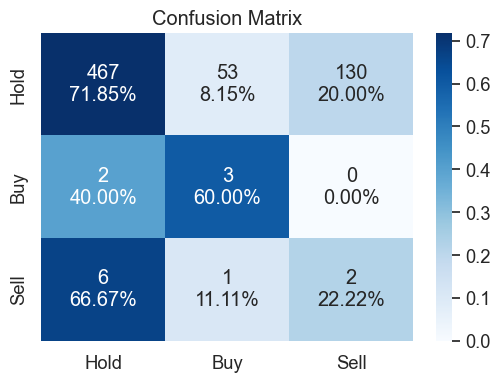

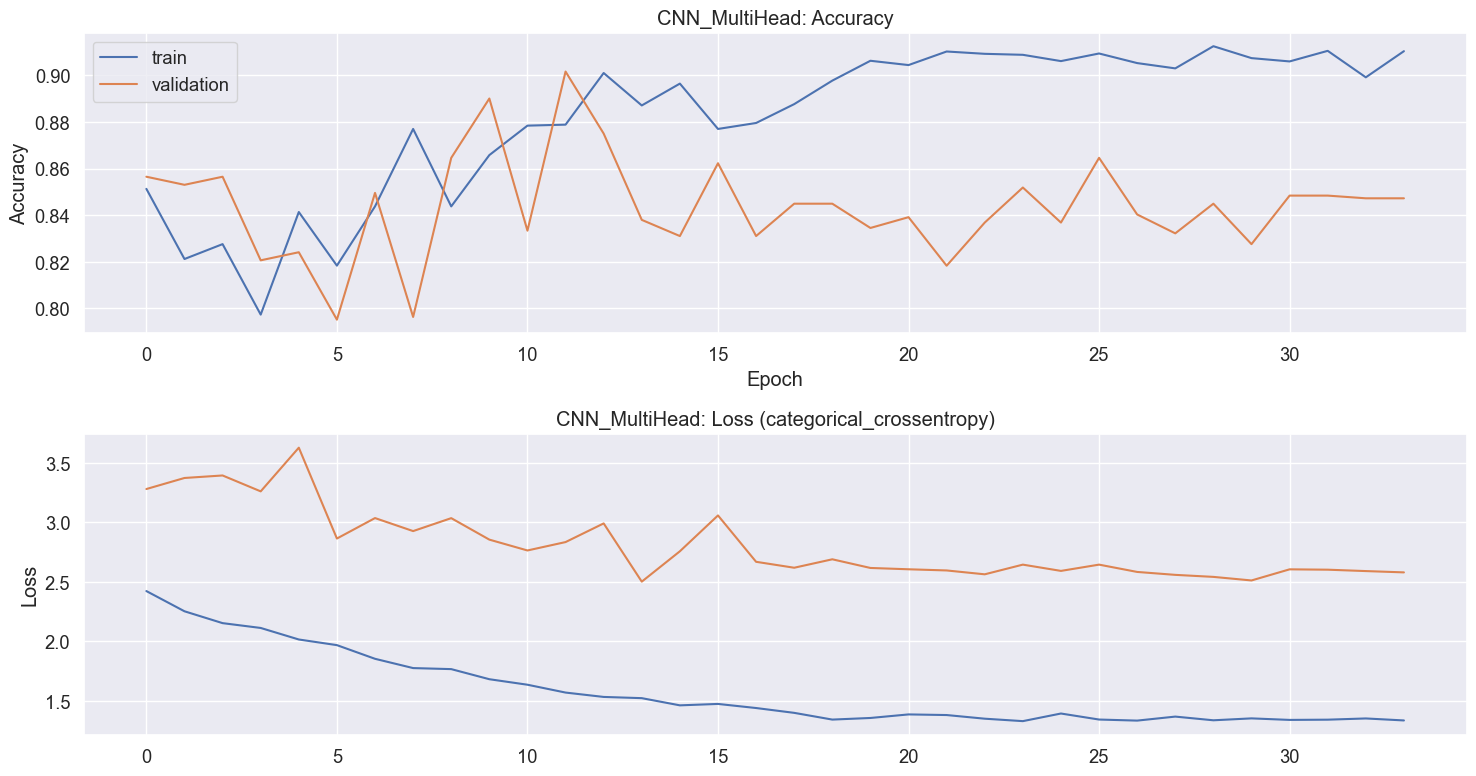

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead
Model name: CNN_MultiHead
27/27 [==============================] - 0s 2ms/step
CNN_MultiHead  classification Accuracy 0.7858796296296298
BTC Dataset Period:2018-01-01 : 2023-01-01
Donwload the file Data_history/BTC_4h.csv from bincance history.
20
Calculating labels
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (8000,)
Vall data shape (1000,)
Test data shape (1002,)
8000
Calculating labels
self.pred_days 66


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:109: RuntimeWarning:

invalid value encountered in divide



input data shape (7980, 20, 20)
output data shape (7980, 3)
1000
Calculating labels
self.pred_days 66
input data shape (980, 20, 20)
output data shape (980, 3)
1002
Calculating labels
self.pred_days 66
input data shape (982, 20, 20)
output data shape (982, 3)
[0 1 2] [7814   84   82]
[ 0.34041464 31.66666667 32.43902439]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200

Epoch 1: val_loss did not improve from 2.50217
1995/1995 - 13s - loss: 1.9458 - accuracy: 0.8071 - matthews_correlation_coefficient: 0.7095 - val_loss: 2.5060 - val_accuracy: 0.6990 - val_matthews_correlation_coefficient: 0.5410 - lr: 1.0000e-04 - 13s/epoch - 7ms/step
Epoch 2/200

Epoch 2: val_loss improved from 2.50217 to 1.82779, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1995/1995 - 13s - loss: 1.6773 - accuracy: 0.7409 - matthews_correlation_coefficient: 0.6104 - val_loss: 1.8278 - val_accuracy: 0.6653 - val_matthews_correlation_coefficient: 0.4980 - lr: 1.0000e-04 - 13s/epoch - 6ms/step
Epoch 3/200

Epoch 3: val_loss did not improve from 1.82779
1995/1995 - 11s - loss: 1.5735 - accuracy: 0.7602 - matthews_correlation_coefficient: 0.6379 - val_loss: 1.9850 - val_accuracy: 0.6612 - val_matthews_correlation_coefficient: 0.4918 - lr: 1.0000e-04 - 11s/epoch - 6ms/step
Epoch 4/200

Epoch 4: val_loss improved from 1.82779 to 1.76177, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


...

1995/1995 - 12s - loss: 1.1614 - accuracy: 0.8315 - matthews_correlation_coefficient: 0.7465 - val_loss: 1.3097 - val_accuracy: 0.7633 - val_matthews_correlation_coefficient: 0.6478 - lr: 1.0000e-04 - 12s/epoch - 6ms/step
Epoch 17/200

Epoch 17: val_loss did not improve from 1.30965
1995/1995 - 11s - loss: 1.1122 - accuracy: 0.8511 - matthews_correlation_coefficient: 0.7762 - val_loss: 1.3563 - val_accuracy: 0.7520 - val_matthews_correlation_coefficient: 0.6244 - lr: 1.0000e-04 - 11s/epoch - 5ms/step
Epoch 18/200

Epoch 18: val_loss did not improve from 1.30965
1995/1995 - 11s - loss: 1.0830 - accuracy: 0.8622 - matthews_correlation_coefficient: 0.7936 - val_loss: 1.3739 - val_accuracy: 0.7816 - val_matthews_correlation_coefficient: 0.6712 - lr: 1.0000e-04 - 11s/epoch - 5ms/step
Epoch 19/200

Epoch 19: val_loss did not improve from 1.30965
1995/1995 - 11s - loss: 1.0628 - accuracy: 0.8704 - matthews_correlation_coefficient: 0.8056 - val_loss: 1.3149 - val_accuracy: 0.7633 - val_matthew

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1995/1995 - 14s - loss: 1.0718 - accuracy: 0.8635 - matthews_correlation_coefficient: 0.7950 - val_loss: 1.2926 - val_accuracy: 0.7286 - val_matthews_correlation_coefficient: 0.5956 - lr: 1.0000e-04 - 14s/epoch - 7ms/step
Epoch 22/200

Epoch 22: val_loss did not improve from 1.29263
1995/1995 - 10s - loss: 1.0024 - accuracy: 0.8788 - matthews_correlation_coefficient: 0.8173 - val_loss: 1.3369 - val_accuracy: 0.7510 - val_matthews_correlation_coefficient: 0.6234 - lr: 1.0000e-04 - 10s/epoch - 5ms/step
Epoch 23/200

Epoch 23: val_loss improved from 1.29263 to 1.27259, saving model to models\model_CNN_MultiHead_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1995/1995 - 12s - loss: 1.0005 - accuracy: 0.8803 - matthews_correlation_coefficient: 0.8200 - val_loss: 1.2726 - val_accuracy: 0.7653 - val_matthews_correlation_coefficient: 0.6469 - lr: 1.0000e-04 - 12s/epoch - 6ms/step
Epoch 24/200

Epoch 24: val_loss did not improve from 1.27259
1995/1995 - 10s - loss: 0.9903 - accuracy: 0.8673 - matthews_correlation_coefficient: 0.8006 - val_loss: 1.4530 - val_accuracy: 0.7265 - val_matthews_correlation_coefficient: 0.5898 - lr: 1.0000e-04 - 10s/epoch - 5ms/step
Epoch 25/200

Epoch 25: val_loss did not improve from 1.27259
1995/1995 - 10s - loss: 0.9610 - accuracy: 0.8799 - matthews_correlation_coefficient: 0.8195 - val_loss: 1.3263 - val_accuracy: 0.8122 - val_matthews_correlation_coefficient: 0.7184 - lr: 1.0000e-04 - 10s/epoch - 5ms/step
Epoch 26/200

Epoch 26: val_loss did not improve from 1.27259
1995/1995 - 10s - loss: 0.9242 - accuracy: 0.9023 - matthews_correlation_coefficient: 0.8530 - val_loss: 1.5500 - val_accuracy: 0.7735 - val_matthew

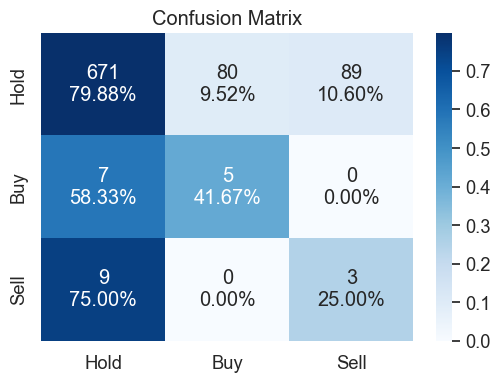

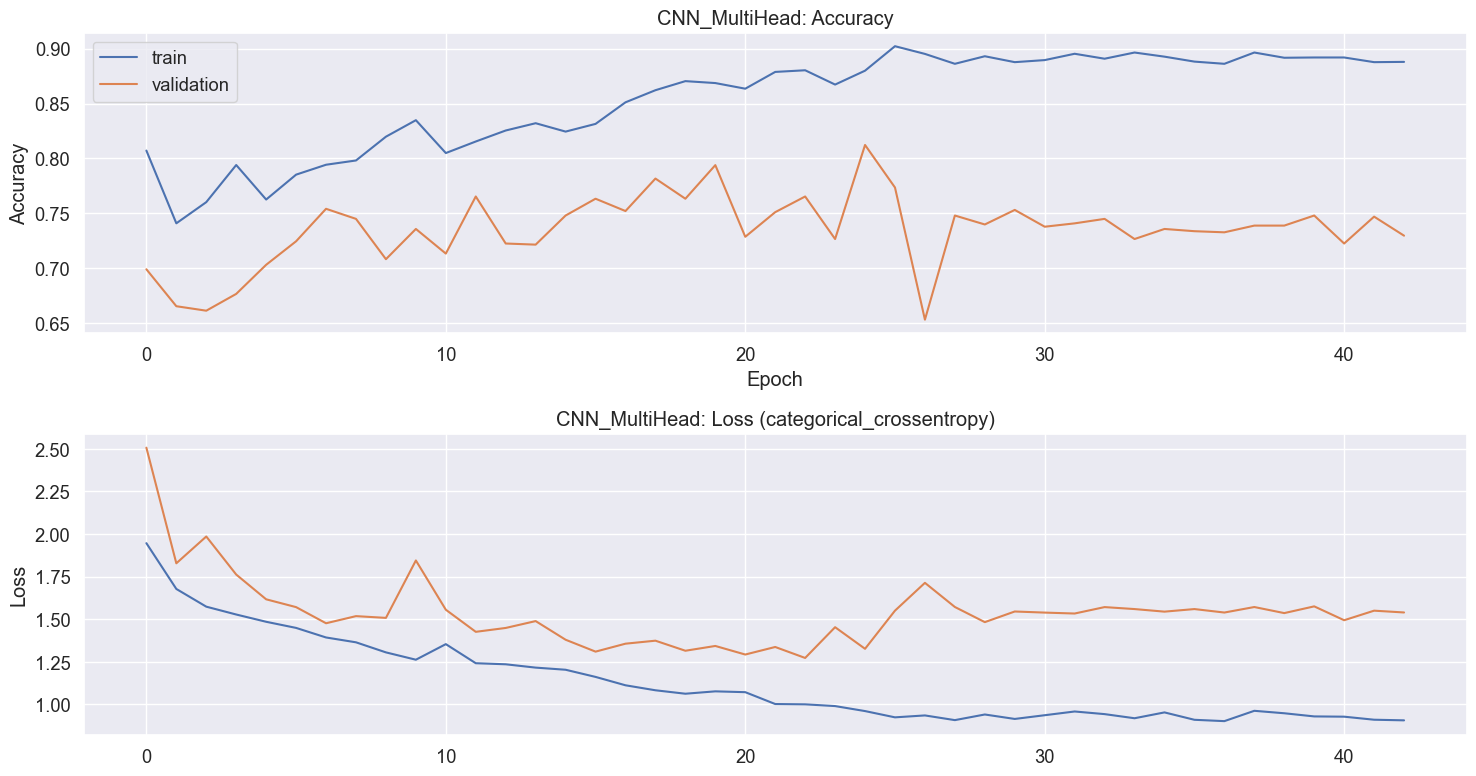

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead
Model name: CNN_MultiHead
31/31 [==============================] - 0s 3ms/step
CNN_MultiHead  classification Accuracy 0.8136456211812626
BTC Dataset Period:2019-01-01 : 2024-01-01
Donwload the file Data_history/BTC_4h.csv from bincance history.
20
Calculating labels
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (8000,)
Vall data shape (1000,)
Test data shape (1002,)
8000
Calculating labels
self.pred_days 66


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:109: RuntimeWarning:

invalid value encountered in divide



input data shape (7980, 20, 20)
output data shape (7980, 3)
1000
Calculating labels
self.pred_days 66
input data shape (980, 20, 20)
output data shape (980, 3)
1002
Calculating labels
self.pred_days 66
input data shape (982, 20, 20)
output data shape (982, 3)
[0 1 2] [7804   89   87]
[ 0.34085085 29.88764045 30.57471264]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200

Epoch 1: val_loss did not improve from 1.27259
1995/1995 - 13s - loss: 1.7163 - accuracy: 0.7326 - matthews_correlation_coefficient: 0.5979 - val_loss: 1.7426 - val_accuracy: 0.5684 - val_matthews_correlation_coefficient: 0.3493 - lr: 1.0000e-04 - 13s/epoch - 7ms/step
Epoch 2/200

Epoch 2: val_loss did not improve from 1.27259
1995/1995 - 10s - loss: 1.3997 - accuracy: 0.6446 - matthews_correlation_coefficient: 0.4654 - val_loss: 1.6470 - val_accuracy: 

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_20\assets


1995/1995 - 12s - loss: 1.1911 - accuracy: 0.6718 - matthews_correlation_coefficient: 0.5061 - val_loss: 1.1506 - val_accuracy: 0.6867 - val_matthews_correlation_coefficient: 0.5301 - lr: 1.0000e-04 - 12s/epoch - 6ms/step
Epoch 5/200

Epoch 5: val_loss did not improve from 1.15061
1995/1995 - 10s - loss: 1.1605 - accuracy: 0.7099 - matthews_correlation_coefficient: 0.5653 - val_loss: 1.1642 - val_accuracy: 0.7153 - val_matthews_correlation_coefficient: 0.5730 - lr: 1.0000e-04 - 10s/epoch - 5ms/step
Epoch 6/200

Epoch 6: val_loss did not improve from 1.15061
1995/1995 - 10s - loss: 1.1310 - accuracy: 0.7142 - matthews_correlation_coefficient: 0.5706 - val_loss: 1.1524 - val_accuracy: 0.6602 - val_matthews_correlation_coefficient: 0.4872 - lr: 1.0000e-04 - 10s/epoch - 5ms/step
Epoch 7/200

Epoch 7: val_loss did not improve from 1.15061
1995/1995 - 10s - loss: 1.1049 - accuracy: 0.7104 - matthews_correlation_coefficient: 0.5650 - val_loss: 1.3123 - val_accuracy: 0.6561 - val_matthews_corr

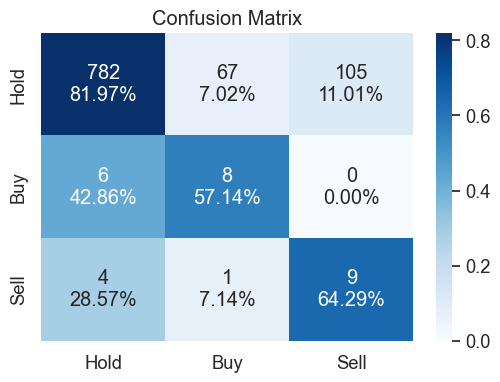

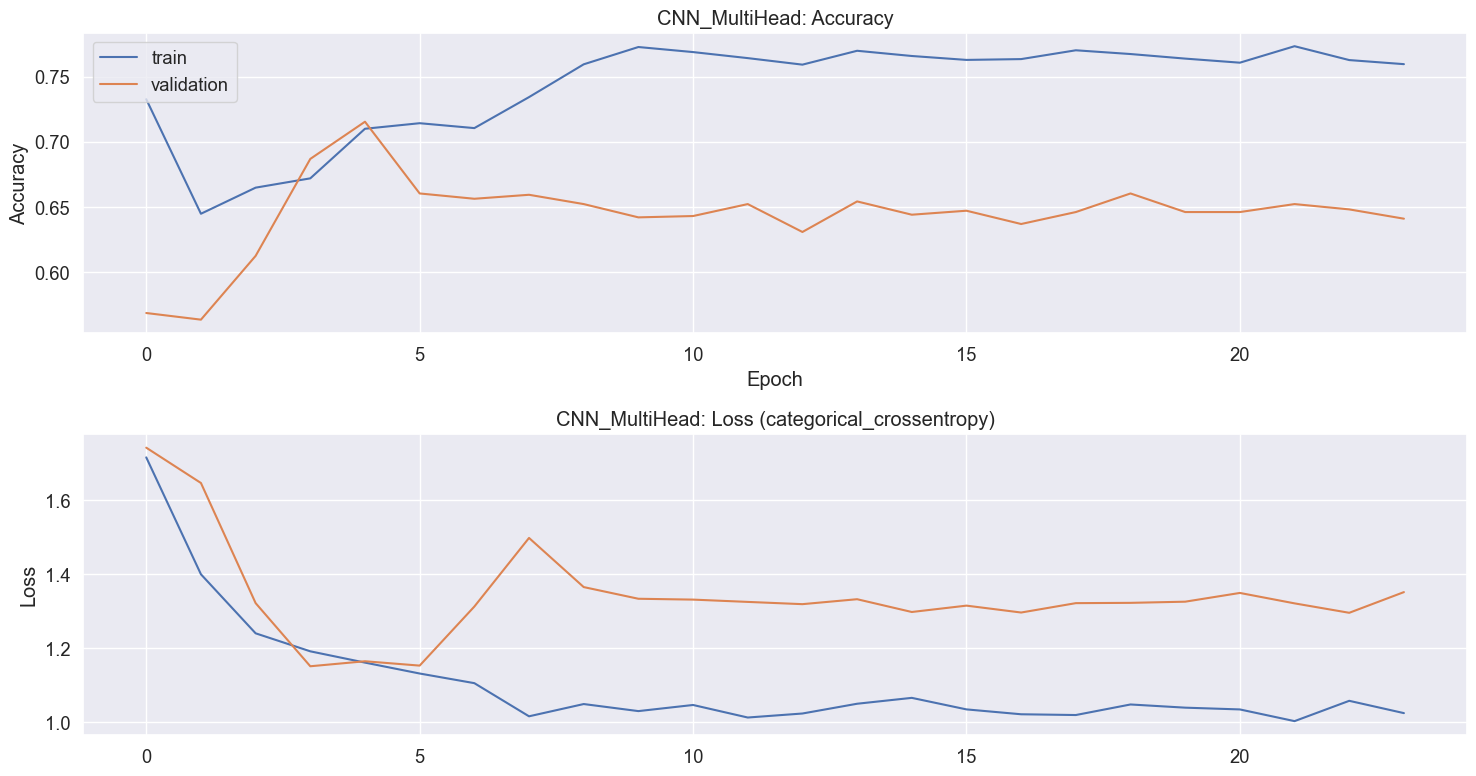

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead
Model name: CNN_MultiHead
31/31 [==============================] - 0s 3ms/step
CNN_MultiHead  classification Accuracy 0.6568228105906314
BTC Dataset Period:2020-01-01 : 2025-01-16
Donwload the file Data_history/BTC_4h.csv from bincance history.
20
Calculating labels
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (8061,)
Vall data shape (1008,)
Test data shape (1009,)
8061
Calculating labels
self.pred_days 66


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:109: RuntimeWarning:

invalid value encountered in divide



input data shape (8041, 20, 20)
output data shape (8041, 3)
1008
Calculating labels
self.pred_days 66
input data shape (988, 20, 20)
output data shape (988, 3)
1009
Calculating labels
self.pred_days 66
input data shape (989, 20, 20)
output data shape (989, 3)
[0 1 2] [7867   84   90]
[ 0.3407059  31.90873016 29.78148148]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200

Epoch 1: val_loss did not improve from 1.15061
2010/2010 - 13s - loss: 1.1995 - accuracy: 0.7516 - matthews_correlation_coefficient: 0.6258 - val_loss: 1.1716 - val_accuracy: 0.6984 - val_matthews_correlation_coefficient: 0.5497 - lr: 1.0000e-04 - 13s/epoch - 6ms/step
Epoch 2/200

Epoch 2: val_loss did not improve from 1.15061
2010/2010 - 10s - loss: 1.1455 - accuracy: 0.6971 - matthews_correlation_coefficient: 0.5451 - val_loss: 1.3950 - val_accuracy: 

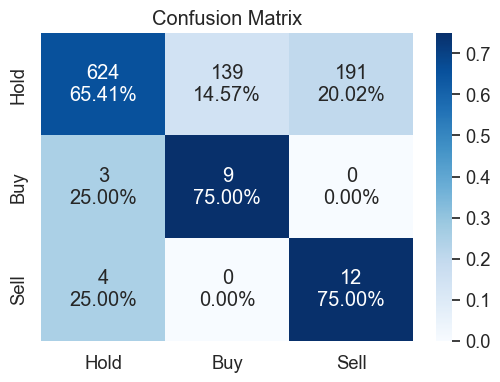

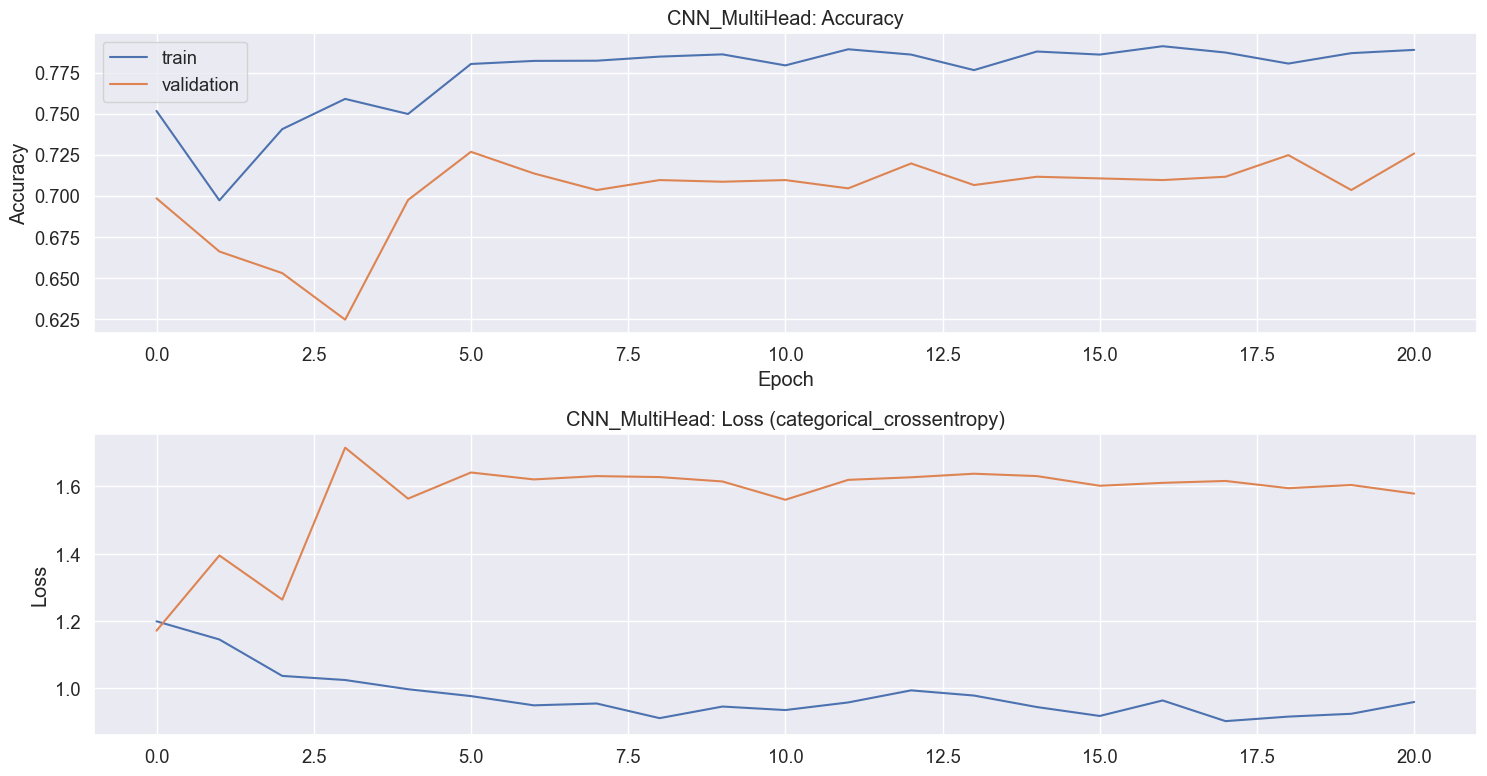

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead
Model name: CNN_MultiHead
31/31 [==============================] - 0s 3ms/step
CNN_MultiHead  classification Accuracy 0.6016177957532861


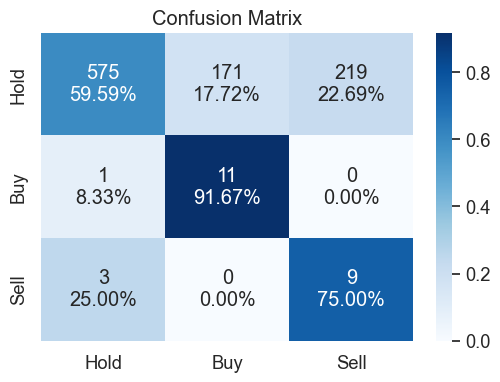

In [17]:
idx=0
for i, cryptos in enumerate(cryptos_list):

    for stride_year in range(0, diff_years-year_window+1):
        init_time=f'{init_date_object.year+stride_year}-01-01'

        look_year=init_date_object.year+stride_year+year_window
        if date_now.year == look_year:
            end_time=date_now.strftime('%Y-%m-%d')
        else:
            end_time=f'{look_year}-01-01'
        print(f'{cryptos} Dataset Period:{init_time} : {end_time}') 

        
        if os.path.exists(file_folder):
            print(f"The file {file_folder} exist in folder path.")
            cryptos_df=pd.read_csv(file_folder, index_col=0)

            mask = (cryptos_df['Date'] >= init_time) & (cryptos_df['Date'] <= end_time)
            cryptos_df = cryptos_df[mask]

        else:
            print(f"Donwload the file {file_folder} from bincance history.")
            # Obtenha os dados históricos
            cryptos_df = SHD.get_crypto_historical_data([cryptos], interval, init_time, end_time)
        
        # split the data in train validation and test
        split_data=FeaturesDataGenerator().split_data
        X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.8)
        X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

        print('Train data shape',X_train.shape)
        print('Vall data shape',X_val.shape)
        print('Test data shape',X_test.shape)

        # get train vall and test dataloader
        X_data_gen_train = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_train)].iloc[:,:], lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation= data_augmentation, min_max_norm=[min_norm, max_norm])
        X_data_gen_val = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_val)].iloc[:,:], lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation= data_augmentation, min_max_norm=[min_norm, max_norm])
        X_data_gen_test = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_test)].iloc[:,:], lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= False, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])

        # get classes weigths 
        Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
        n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
        print(n_classes, counts)
        output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))

        # Ajusta o peso da primeira classe
        #adjustment_factor = 2
        #output_class_weights[2] = output_class_weights[2] * adjustment_factor

        # Normaliza os pesos novamente
        #output_class_weights = output_class_weights / np.sum(output_class_weights)
        print(output_class_weights)
        #output_class_weights = np.ones(3) 
        weighted_categorical_crossentropy_loss= X_data_gen_train.weighted_categorical_crossentropy(output_class_weights)

        loss = weighted_categorical_crossentropy_loss
        #loss = MSE
        for idx_model, model in enumerate(list_of_models):

            if idx == 0:  
                optimizer = get_optimizer()
                csvLogger, model_checkpoint_callback  = checkpoints(model._name)
                model.compile(loss=[loss], optimizer=optimizer, metrics=['accuracy',matthews_correlation_coefficient])
                idx=1
            else:
                model = trained_best_models[model._name]
                
            print('------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
            print(f'Initing train fo model: {model._name}')

            history = model.fit(
                X_data_gen_train,
                epochs=200,
                callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback, csvLogger],
                validation_data=X_data_gen_val,
                #shuffle=True,
                verbose=2
            )
            # Assuming history_metric, history_metric_val, history are defined elsewhere

            fig, axes = plt.subplots(2, 1, figsize=(15, 8))  # Create subplots programmatically

            # Plot accuracy, sharing x-axis with NRMSE
            axes[0].plot(history.history['accuracy'])
            axes[0].plot(history.history['val_accuracy'])
            axes[0].set_title(f'{model._name}: Accuracy')
            axes[0].set_ylabel('Accuracy')
            axes[0].set_xlabel('Epoch')  # Shared x-axis label
            axes[0].legend(['train', 'validation'], loc='upper left')

            # Plot loss
            axes[1].plot(history.history['loss'])
            axes[1].plot(history.history['val_loss'])
            axes[1].set_title(f'{model._name}: Loss (categorical_crossentropy)')
            axes[1].set_ylabel('Loss')

            # Adjust spacing and margins (optional)
            plt.subplots_adjust(left=0.1, bottom=0.15, right=0.9, top=0.9, wspace=0.2)

            # Fine-tune spacing (optional)
            plt.tight_layout()

            plt.show()

        trained_best_models={}
        
        print("---------------------------------------------------------------------------------------------------------------------------------")
        for model in list_of_models:
            print(model.name)
            checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}'
            trained_best_models[f'{model._name}']=tf.keras.models.load_model(
                checkpoint_filepath, 
                custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient}, 
                compile=True)

            print('Model name:',model_name)

            x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)

            label_pred = trained_best_models[model_name].predict(x_data)
            print(model_name,' classification Accuracy',
                            utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                            np.argmax(label_pred,axis=1),average="micro"))

            cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
            
            try:
                utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
            except:
                print(cf_matrix)

In [18]:
Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
print(n_classes, counts)

[0 1 2] [7867   84   90]


In [19]:
# get classes weigths 
Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
print(n_classes, counts)

[0 1 2] [7867   84   90]


Model name: CNN_MultiHead
31/31 [==============================] - 0s 3ms/step
CNN_MultiHead  classification Accuracy 0.6016177957532861


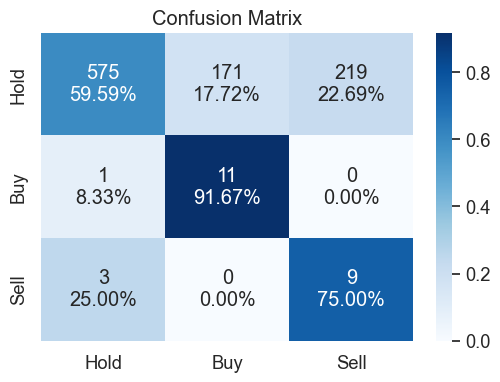

In [20]:
import utils
model_name = "CNN_MultiHead"    
for model_name in list_of_models:
    model_name = model_name._name
    print('Model name:',model_name)

    x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)

    label_pred = trained_best_models[model_name].predict(x_data)
    print(model_name,' classification Accuracy',
                    utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                    np.argmax(label_pred,axis=1),average="micro"))

    cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
    
    try:
        utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
    except:
        print(cf_matrix)

Model name: CNN_MultiHead
31/31 [==============================] - 0s 3ms/step
CNN_MultiHead  classification Accuracy 0.5961538461538461


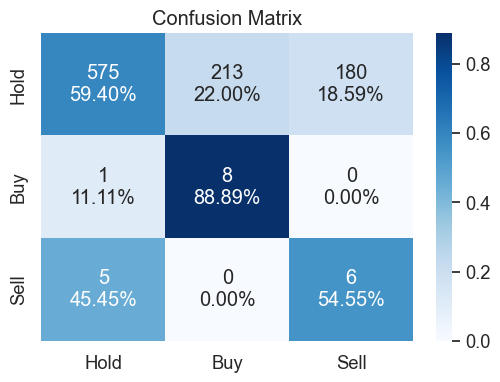

In [21]:
model_name = "CNN_MultiHead"  
print('Model name:',model_name)

x_data=X_data_gen_val.apply_NomrMinmax(X_data_gen_val.features, min_norm,  max_norm, axis=0)

label_pred = trained_best_models[model_name].predict(x_data)
print(model_name,' classification Accuracy',
                utils.f1_score(np.argmax(X_data_gen_val.y_classification,axis=1),
                np.argmax(label_pred,axis=1),average="micro"))

cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_val.y_classification,axis=1),np.argmax(label_pred,axis=1))
 
try:
    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
except:
    print(cf_matrix)

In [22]:
# Classe para gerenciar o backtesting
import matplotlib.pyplot as plt

class Backtester:
    def __init__(self, initial_balance, data):
        self.initial_balance = initial_balance
        self.data = data
        self.balance = initial_balance
        self.position = 0
        self.portfolio_value = []

    def execute_trade(self, signal, price):
        if signal == 'Buy' and self.balance > 0:
            self.position = self.balance / price
            self.balance = 0
        elif signal == 'Sell' and self.position > 0:
            self.balance = self.position * price
            self.position = 0

    def run(self, signals):
        for i in range(len(self.data)):
            price = self.data['Close'].iloc[i]
            signal = signals[i]

            self.execute_trade(signal, price)
            portfolio_value = self.balance + (self.position * price)
            self.portfolio_value.append(portfolio_value)

    def plot_results(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.data.index, self.portfolio_value, label='Portfolio Value')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.title('Portfolio Performance')
        plt.legend()
        plt.show()

# Função para gerar sinais fictícios
def generate_signals(signals):
    trade_signals = ['Hold']
    for i in range(1,len(signals)):
        if signals[i] == 'Buy' and signals[i-1] == 'Buy':
            trade_signals.append('Hold')
        elif signals[i] == 'Buy' and signals[i-1] == 'Hold':
            trade_signals.append('Buy')
        elif signals[i] == 'Sell' and signals[i-1] == 'Sell':
            trade_signals.append('Hold')

        elif signals[i] == 'Sell' and signals[i-1] == 'Hold':
            trade_signals.append('Sell')
        else:
            trade_signals.append('Hold')


    return trade_signals

10076
Calculating labels
self.pred_days 66
input data shape (10056, 20, 20)
output data shape (10056, 3)
315/315 [==============================] - 1s 3ms/step
(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([2098, 5943, 2015], dtype=int64))


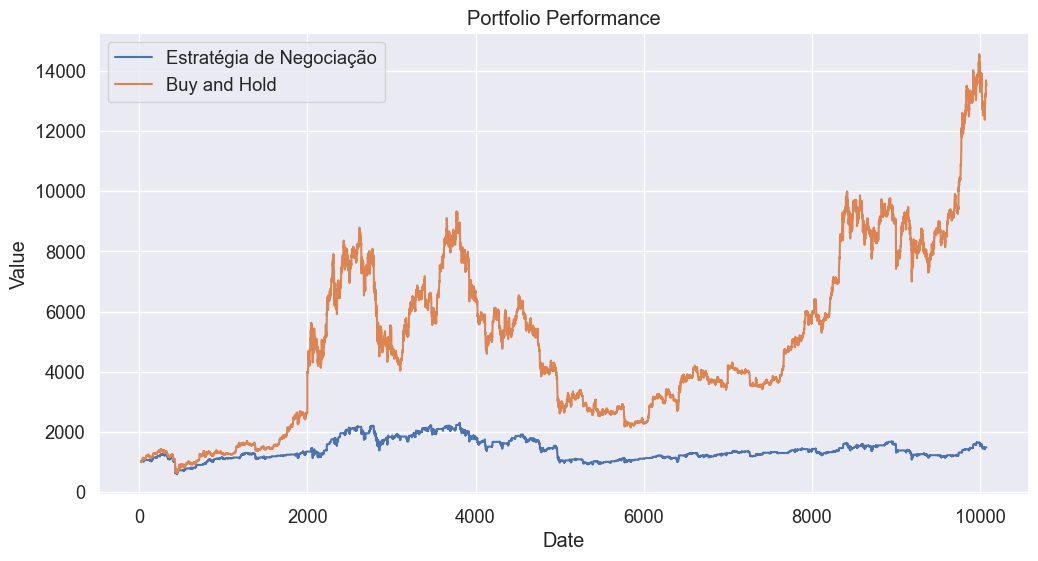

Trade prediction return: 47.78%
Buy and Hold strategy return: 1251.32%
10056
Calculating labels


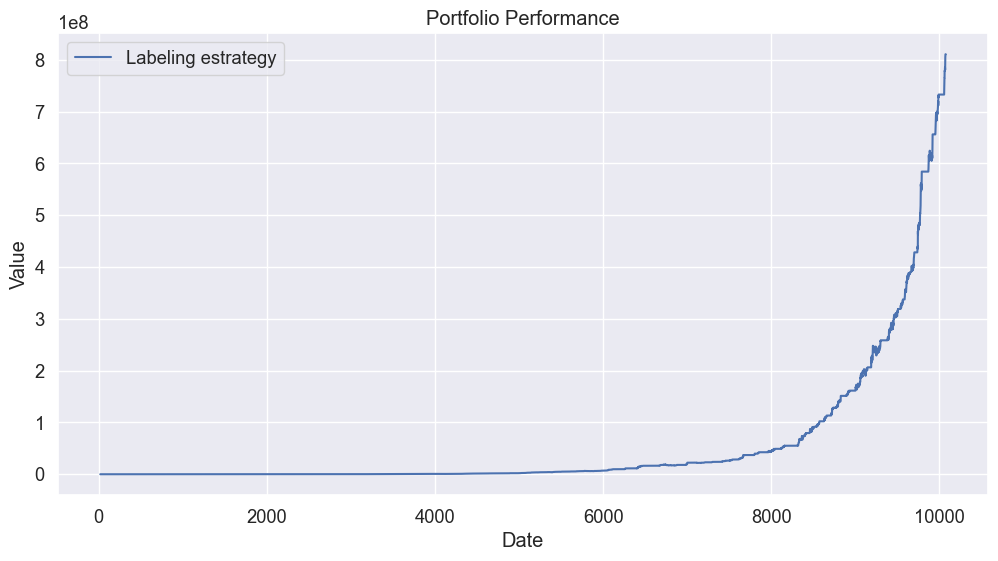

Labeling strategy return: 81085736.97%


In [23]:
# Parâmetros iniciais
symbol=['BTC']
interval = '4h'
start_time = '2020-01-01'
initial_balance = 1000

# Coleta de dados
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

dataGen_inference = FeaturesDataGenerator(data, lookback = lookback, pred_days = pred_days, shuffle= False, batch_size=1, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
if data.empty:
    print("Nenhum dado encontrado.")
else:
    # Geração de sinais e backtesting

    x_data_inference=dataGen_inference.comput_features(data, pred_days=0)
    x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    
    #list_of_models =['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
    model_name='CNN_MultiHead'
    label_pred = trained_best_models[model_name].predict(x_data)

    signals = [trade[label] for label in np.argmax(label_pred[:], axis=1)]
    print(np.unique(signals, return_counts=True))
    
    #pred_trade_signals=generate_signals(signals)
    
    pred_trade_signals=signals
    data=data.iloc[-len(signals):,:]


    backtester = Backtester(initial_balance, data)
    backtester.run(pred_trade_signals)
    #backtester.plot_results()

    # Estratégia de buy and hold
    buy_and_hold = Backtester(initial_balance, data)
    signals = ['Buy'] + ['Hold'] * (len(data) - 1)
    buy_and_hold.run(signals)
    buy_and_hold_value = buy_and_hold.portfolio_value
    

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
    plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()
    
        # Calcular retorno
    backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
    buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

    print(f"Trade prediction return: {backtester_return * 100:.2f}%")
    print(f"Buy and Hold strategy return: {buy_and_hold_return * 100:.2f}%")
    
    label_data = dataGen_inference.label_data(close_prices=data['Close'].values, window=pred_days)
    
    trade_signals=[("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
        for label in label_data]# Realizar o backtest
    
    #data=data.iloc[:len(trade_signals),:]

    Labeling_backtester = Backtester(initial_balance, data)
    Labeling_backtester.run(trade_signals)

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(Labeling_backtester.data.index, Labeling_backtester.portfolio_value, label='Labeling estrategy')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()

    # Calcular retorno
    labeling_backtester_return = (Labeling_backtester.portfolio_value[-1] - initial_balance) / initial_balance

    print(f"Labeling strategy return: {labeling_backtester_return * 100:.2f}%")

10056
Calculating labels


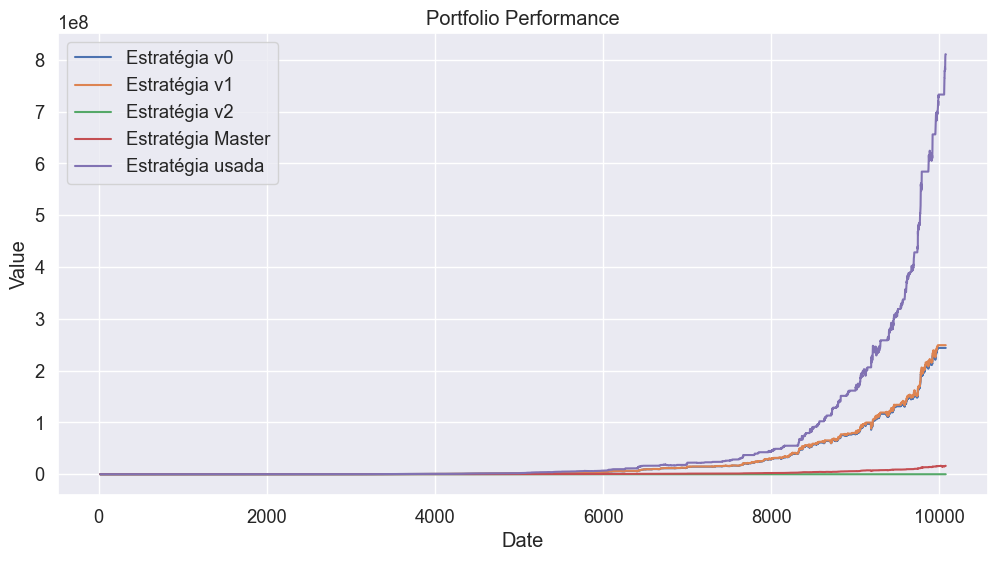

Estratégia v0: 24388280.82%
Estratégia v1: 24920695.65%
Estratégia v2: 803.37%
Estratégia Master: 1620296.58%
Estratégia Master Testada: 81085736.97%


In [24]:
# Implementar todas as estratégias
label_data_v0 = dataGen_inference.label_data_v0(close_prices=data['Close'].values, window=pred_days)
label_data_v1 = dataGen_inference.label_data_v1(close_prices=data['Close'].values, window=pred_days)
label_data_v2 = dataGen_inference.label_data_v2(close_prices=data['Close'].values, window=pred_days)
label_data_master = dataGen_inference.label_data_master(close_prices=data['Close'].values, window=pred_days)
label_data = dataGen_inference.label_data(close_prices=data['Close'].values, window=pred_days)

# Convertar as labels em sinais de compra e venda
trade_signals_v0 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v0]
trade_signals_v1 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v1]
trade_signals_v2 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v2]
trade_signals_master = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_master]
trade_signals = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data]

# Realizar o backtest
backtester_v0 = Backtester(initial_balance, data)
backtester_v0.run(trade_signals_v0)

backtester_v1 = Backtester(initial_balance, data)
backtester_v1.run(trade_signals_v1)

backtester_v2 = Backtester(initial_balance, data)
backtester_v2.run(trade_signals_v2)

backtester_master = Backtester(initial_balance, data)
backtester_master.run(trade_signals_master)

backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)

# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester_v0.data.index, backtester_v0.portfolio_value, label='Estratégia v0')
plt.plot(backtester_v1.data.index, backtester_v1.portfolio_value, label='Estratégia v1')
plt.plot(backtester_v2.data.index, backtester_v2.portfolio_value, label='Estratégia v2')
plt.plot(backtester_master.data.index, backtester_master.portfolio_value, label='Estratégia Master')
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia usada')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular o retorno de cada estratégia
retorno_v0 = (backtester_v0.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v1 = (backtester_v1.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v2 = (backtester_v2.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master = (backtester_master.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master_tested = (backtester.portfolio_value[-1] - initial_balance) / initial_balance

# Imprimir os resultados
print(f"Estratégia v0: {retorno_v0 * 100:.2f}%")
print(f"Estratégia v1: {retorno_v1 * 100:.2f}%")
print(f"Estratégia v2: {retorno_v2 * 100:.2f}%")
print(f"Estratégia Master: {retorno_master * 100:.2f}%")
print(f"Estratégia Master Testada: {retorno_master_tested * 100:.2f}%")